Program started...
Dataset loaded: Using 500 records
Calculating predictions...
Prediction completed


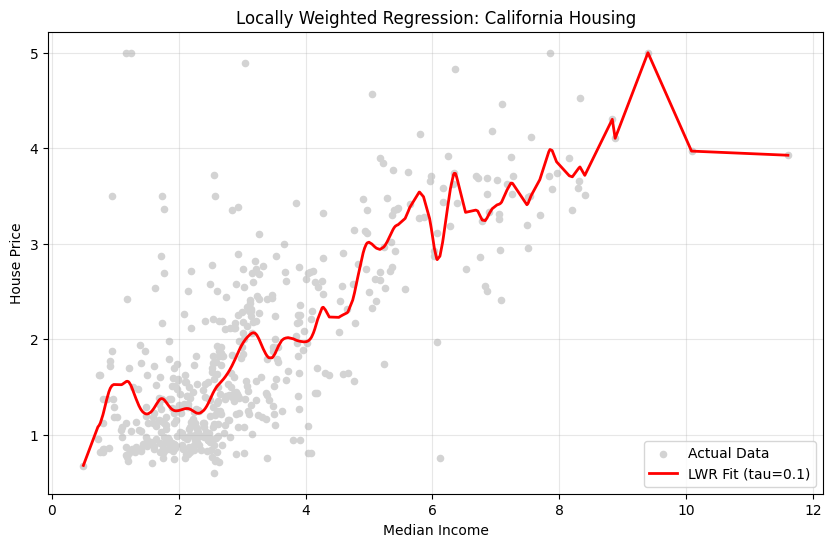

Done.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

print("Program started...")

# 1. Load dataset - Using return_X_y is the cleanest way for Scikit-Learn
X_all, Y_all = fetch_california_housing(return_X_y=True)

# 2. Select first feature (Median Income) and first 500 records
# We reshape X to be a 2D array for consistency
X = X_all[:500, 0]
Y = Y_all[:500]

print(f"Dataset loaded: Using {len(X)} records")

# 3. Add intercept column (Column of ones)
X_mat = np.c_[np.ones(len(X)), X]

# 4. Bandwidth parameter - Controls "smoothness"
# Smaller tau = fits closer to data (wiggly); Larger tau = smoother
tau = 0.1

# Optimized Locally Weighted Regression Function


def locally_weighted_regression(x_query, X, Y, tau):
    # Vectorized weight calculation (No more internal for-loop!)
    # Formula: w(i) = exp(-(x(i) - x)^2 / (2 * tau^2))
    # X[:, 1] accesses the actual feature values (not the intercept ones)
    weights = np.exp(-((X[:, 1] - x_query) ** 2) / (2 * tau ** 2))
    W = np.diag(weights)

    # Calculate theta using the Normal Equation: theta = (X^T * W * X)^-1 * X^T * W * Y
    # np.linalg.pinv is safer than inv for non-invertible matrices
    theta = np.linalg.pinv(X.T @ W @ X) @ (X.T @ W @ Y)

    # Prediction for the single point
    return np.array([1, x_query]) @ theta


print("Calculating predictions...")

# 5. Generate predictions
y_pred = np.array([locally_weighted_regression(x, X_mat, Y, tau) for x in X])

print("Prediction completed")

# 6. Sort values for a clean line plot
sorted_idx = np.argsort(X)
X_sorted = X[sorted_idx]
Y_sorted = Y[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

# 7. Display Results
plt.figure(figsize=(10, 6))
plt.scatter(X_sorted, Y_sorted, color='lightgray', label='Actual Data', s=20)
plt.plot(X_sorted, y_pred_sorted, color='red',
         lw=2, label=f'LWR Fit (tau={tau})')

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Locally Weighted Regression: California Housing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Done.")
